<a href="https://colab.research.google.com/github/Uggina-Manisha/online-exam-cheating-detection/blob/main/online_exam_cheating_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Online Exam Cheating Detection using ANN**

In [ ]:
# Data handling
import pandas as pd
import numpy as np

# Preprocessing & model evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

# Deep learning
import tensorflow as tf

# Plotting
import matplotlib.pyplot as plt



In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])

print(df.head())
print("Dataset Shape:", df.shape)


Saving online_exam_cheating_dataset_10000 (1).csv to online_exam_cheating_dataset_10000 (1).csv
   time_taken  avg_time_per_question  answer_similarity  copy_paste_count  \
0          66                   2.14              0.519                12   
1          29                   2.01              0.673                 3   
2          86                   2.76              0.044                 6   
3          75                   0.35              0.221                 1   
4          35                   1.80              0.456                 2   

   tab_switch_count  label  
0                 8      1  
1                18      1  
2                14      1  
3                 1      0  
4                14      1  
Dataset Shape: (10000, 6)


In [ ]:
# Input features
X = df[['time_taken', 'avg_time_per_question', 'answer_similarity',
        'copy_paste_count', 'tab_switch_count']]

# Output label
y = df['label']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=(5,)),  # Hidden Layer 1
    tf.keras.layers.Dense(16, activation='relu'),                    # Hidden Layer 2
    tf.keras.layers.Dense(1, activation='sigmoid')                   # Output Layer
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6079 - loss: 0.6067 - val_accuracy: 0.9312 - val_loss: 0.1984
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9487 - loss: 0.1625 - val_accuracy: 0.9463 - val_loss: 0.1223
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9563 - loss: 0.1049 - val_accuracy: 0.9606 - val_loss: 0.0968
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9675 - loss: 0.0861 - val_accuracy: 0.9694 - val_loss: 0.0803
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9704 - loss: 0.0734 - val_accuracy: 0.9731 - val_loss: 0.0703
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9721 - loss: 0.0751 - val_accuracy: 0.9800 - val_loss: 0.0613
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9793 - loss: 0.0584 - val_accuracy: 0.9806 - val_loss: 0.0543
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9822 - loss: 0.0530 - val_accuracy: 0.

In [ ]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Test Accuracy: 0.9845
Confusion Matrix:
 [[ 248   21]
 [  10 1721]]


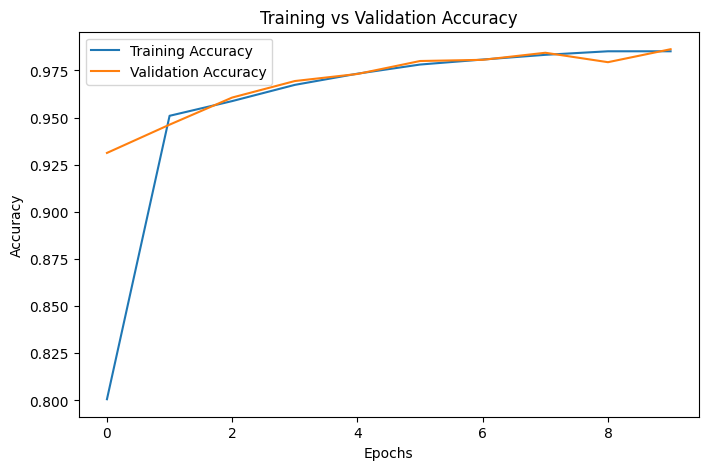

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()


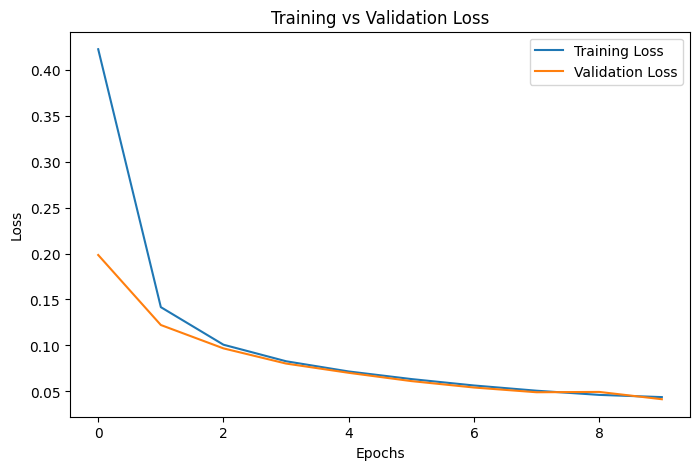

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()


In [ ]:
# Example: a new student
new_student = [[18, 1.2, 0.92, 5, 8]]

# Scale features
new_student_scaled = scaler.transform(new_student)

# Predict
prediction = model.predict(new_student_scaled)

if prediction > 0.5:
    print("Cheating Detected")
else:
    print("Normal Behavior")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Cheating Detected


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
# Example: a new student
new_student = [[60, 3, 0.62, 5, 2]]

# Scale features
new_student_scaled = scaler.transform(new_student)

# Predict
prediction = model.predict(new_student_scaled)

if prediction > 0.5:
    print("Cheating Detected")
else:
    print("Normal Behavior")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Normal Behavior


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
# Evaluate Model
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Test Accuracy: 0.9845
Precision: 0.9879
Recall: 0.9942
F1-score: 0.9911


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
AUC Score: 0.9977085252738709


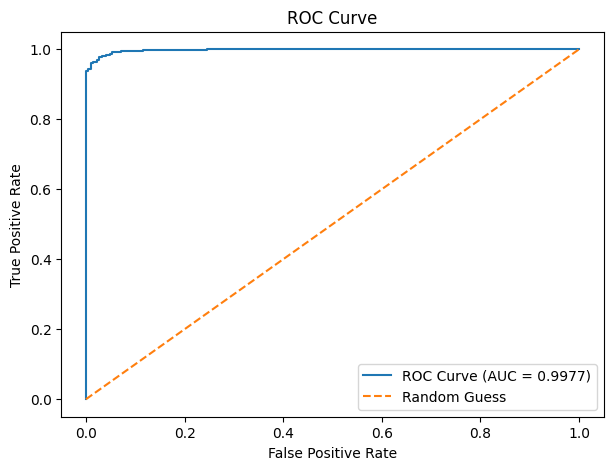

In [ ]:
from sklearn.metrics import roc_curve, auc

# Predict probabilities
y_pred_prob = model.predict(X_test).ravel()

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# Compute AUC
roc_auc = auc(fpr, tpr)
print("AUC Score:", roc_auc)

# Plot ROC Curve
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


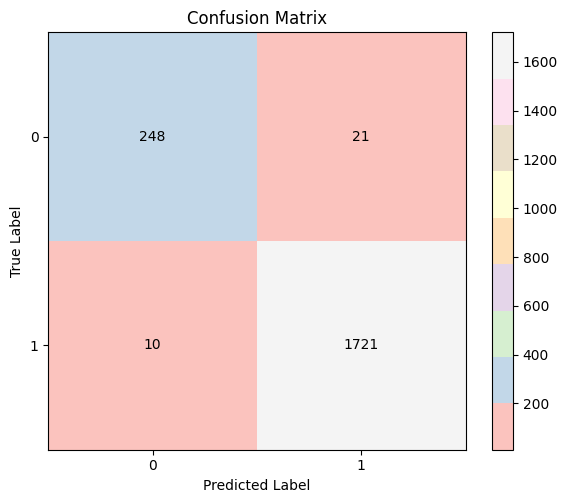

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='Pastel1', alpha=0.8)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0, 1])
plt.yticks([0, 1])

# Add values inside each box
for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


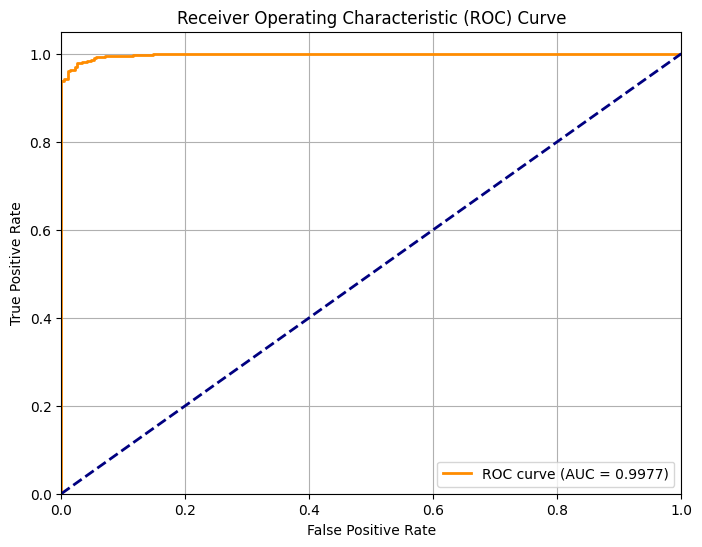

In [ ]:
from sklearn.metrics import roc_curve, auc

# Predict probabilities for the positive class
y_pred_prob = model.predict(X_test).ravel()  # flatten to 1D array

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# Compute AUC
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
